# ライブラリのインポート

In [50]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import src.preprocessing as prep
import random
import os
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

# データセットの読み込み

## メタデータの確認

In [51]:
path = "../data/raw"
files = [f for f in os.listdir(path) if f.endswith(".csv") or f.endswith(".parquet")]
paths = [os.path.join(path, f) for f in files]
dataset_metadata = pd.read_csv("../data/metadata/dataset_metadata.csv")
print("Dataset metadata:\n", dataset_metadata)

Dataset metadata:
               file_name  n_rows  n_columns
0        AEP_hourly.csv  121273          2
1      COMED_hourly.csv   66497          2
2     DAYTON_hourly.csv  121275          2
3       DEOK_hourly.csv   57739          2
4        DOM_hourly.csv  116189          2
5        DUQ_hourly.csv  119068          2
6       EKPC_hourly.csv   45334          2
7    est_hourly.parquet  178262         12
8         FE_hourly.csv   62874          2
9         NI_hourly.csv   58450          2
10      PJME_hourly.csv  145366          2
11      PJMW_hourly.csv  143206          2
12   pjm_hourly_est.csv  178262         13
13  PJM_Load_hourly.csv   32896          2


## 読み込み

In [52]:
index = [i for i, p in enumerate(paths) if "PJME_hourly" in p][0]
df = pd.read_csv(paths[index]) if paths[index].endswith(".csv") else pd.read_parquet(paths[index])
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)

In [53]:
df.shape

(145366, 2)

In [54]:
new_df = prep.get_effective_df(df)

In [55]:
new_df.tail()

,Datetime,PJME_MW
145361,2018-08-02 20:00:00,44057.0
145362,2018-08-02 21:00:00,43256.0
145363,2018-08-02 22:00:00,41552.0
145364,2018-08-02 23:00:00,38500.0
145365,2018-08-03 00:00:00,35486.0


## データセットの分割

In [56]:
# 1年分をテストデータとする
train = new_df[:-24*365].reset_index(drop=True)
test = new_df[-24*365:].reset_index(drop=True)
# if os.path.exists("../data/processed") == False:
#     os.mkdir("../data/processed")
# train.to_csv("../data/processed/train.csv", index=False)
# test.to_csv("../data/processed/test.csv", index=False)
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (136606, 2)
Test shape: (8760, 2)


# 欠損値の確認

In [57]:
train.isnull().sum()

Datetime    0
PJME_MW     0
dtype: int64

In [58]:
test.isnull().sum()

Datetime    0
PJME_MW     0
dtype: int64

In [59]:
# 線形補間の必要はない

# EDA

## 自己相関・偏自己相関

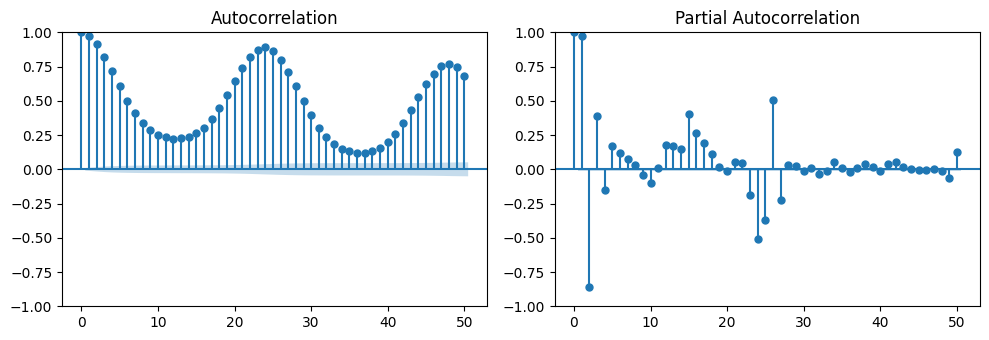

In [60]:
# 予測対象はPJME
# 5年分のデータで自己相関と偏自己相関をプロット
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_acf(train["PJME_MW"][-24*365*5:], lags=50, ax=axes[0])
plot_pacf(train["PJME_MW"][-24*365*5:], lags=50, ax=axes[1])
plt.tight_layout()
plt.show()

24時間（1日）の周期性がありそう。

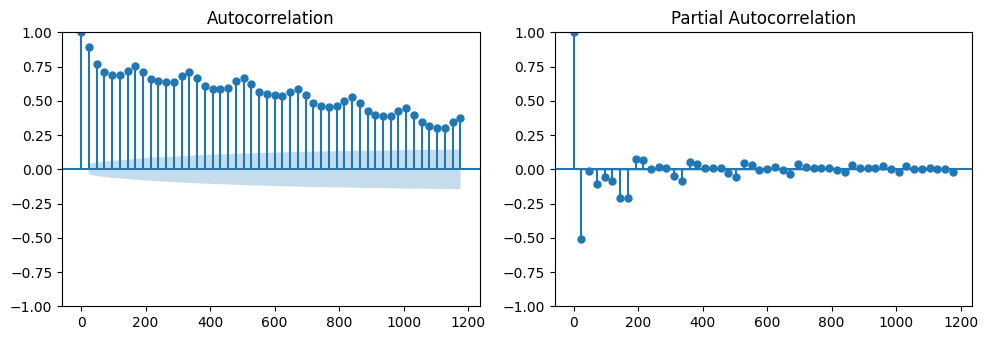

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
lags = np.arange(0, 24*50, 24)
plot_acf(train["PJME_MW"][-24*365*5:], lags=lags, ax=axes[0])
plot_pacf(train["PJME_MW"][-24*365*5:], lags=lags, ax=axes[1])
plt.tight_layout()
plt.show()

In [62]:
# lag24の特徴量はあってもいいかもしれない。

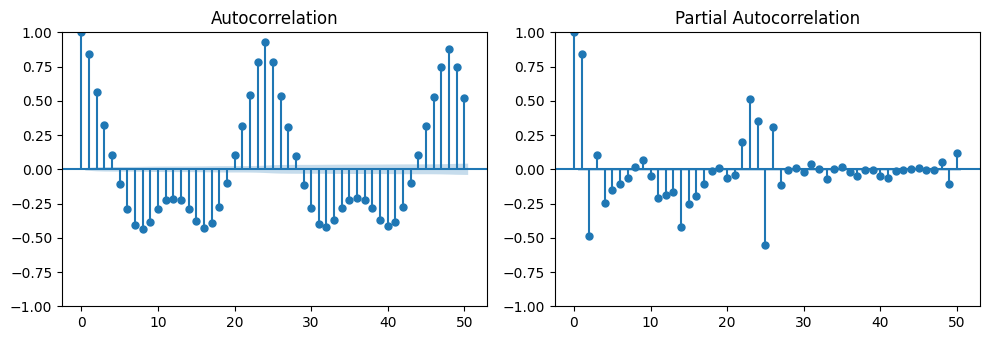

In [63]:
# 差分を取る
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_acf(train["PJME_MW"][-24*365*5:].diff().dropna(), lags=50, ax=axes[0])
plot_pacf(train["PJME_MW"][-24*365*5:].diff().dropna(), lags=50, ax=axes[1])
plt.tight_layout()
plt.show()

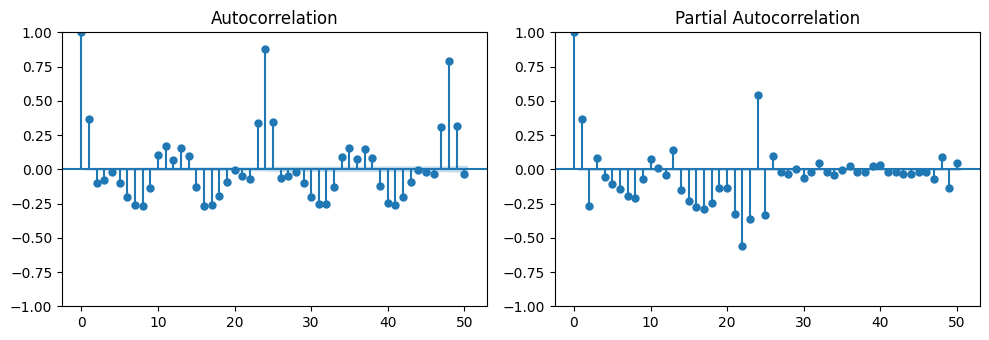

In [64]:
# 二階差分を取る
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_acf(train["PJME_MW"][-24*365*5:].diff().diff().dropna(), lags=50, ax=axes[0])
plot_pacf(train["PJME_MW"][-24*365*5:].diff().diff().dropna(), lags=50, ax=axes[1])
plt.tight_layout()
plt.show()

In [65]:
# 差分をとる前のデータは非定常である可能性が高い。差分を1回、2回とった後の自己相関・偏自己相関を確認したが、安定しない。
# 周期性が確認できるため24時間分で差分をとって自己相関・偏自己相関を確認する。

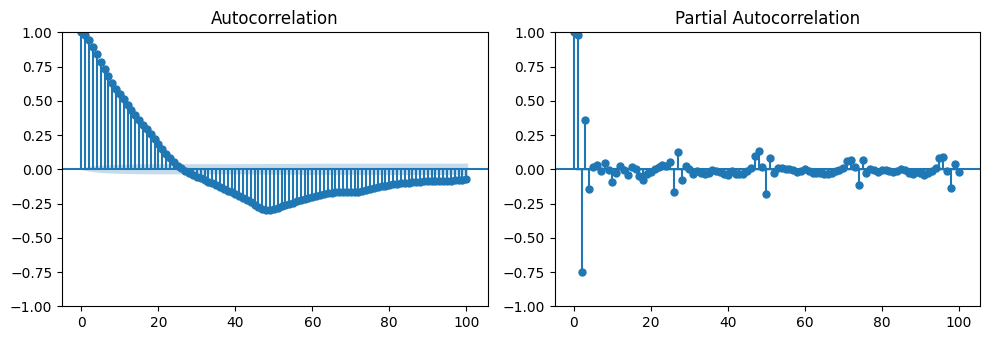

In [66]:
# 1日の差分をとる
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_acf(train["PJME_MW"][-24*365*5:].diff(periods=24).dropna(), lags=100, ax=axes[0])
plot_pacf(train["PJME_MW"][-24*365*5:].diff(periods=24).dropna(), lags=100, ax=axes[1])
plt.tight_layout()
plt.show()

In [67]:
# 1日の差分をとると、ACF,PACFともに安定するように見える。
# 季節性ARIMAモデルを検討する必要があるかもしれない。また、トレンドもある可能性があるため、トレンドを考慮したモデルも検討する必要があるかもしれない。
# トレンドも考えると、差分1と差分24の両方をとる必要があるかもしれない。
# 季節性、トレンドともにあるとしたらSARIMAモデルを検討する必要があるかもしれない。

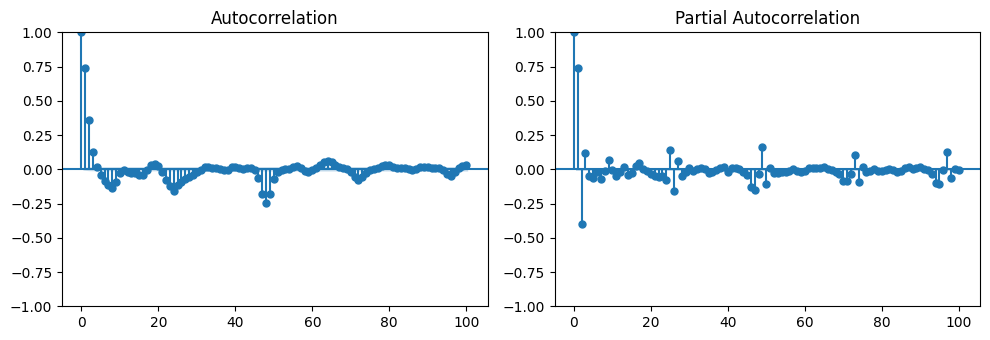

In [68]:
# 1時間の差分でトレンドの打消し、1日の差分で季節性の打消し
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_acf(train["PJME_MW"][-24*365*5:].diff().diff(periods=24).dropna(), lags=100, ax=axes[0])
plot_pacf(train["PJME_MW"][-24*365*5:].diff().diff(periods=24).dropna(), lags=100, ax=axes[1])
plt.tight_layout()
plt.show()

In [69]:
# 1時間の差分と1日の差分をとると、ACF,PACFともに安定するように見える。

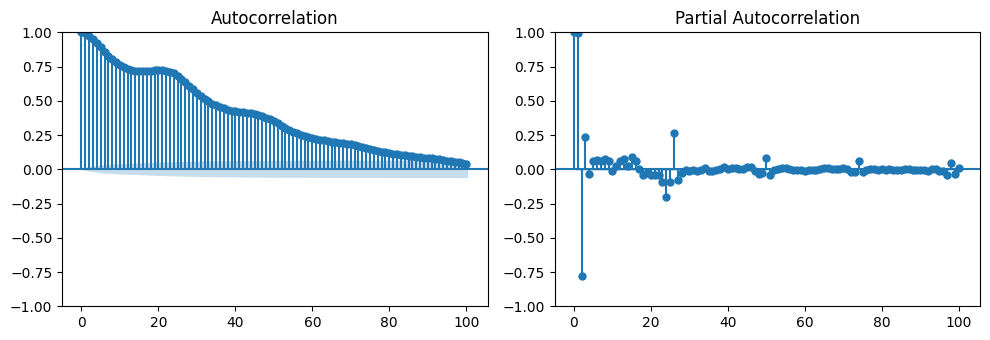

In [70]:
# 1週間の差分をとる
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_acf(train["PJME_MW"][-24*365*5:].diff(periods=24*7).dropna(), lags=100, ax=axes[0])
plot_pacf(train["PJME_MW"][-24*365*5:].diff(periods=24*7).dropna(), lags=100, ax=axes[1])
plt.tight_layout()
plt.show()

In [71]:
# 1週間の差分をとると、ACF,PACFともに安定するように見える。
# lag=24*7の特徴量もあってもいいかもしれない。

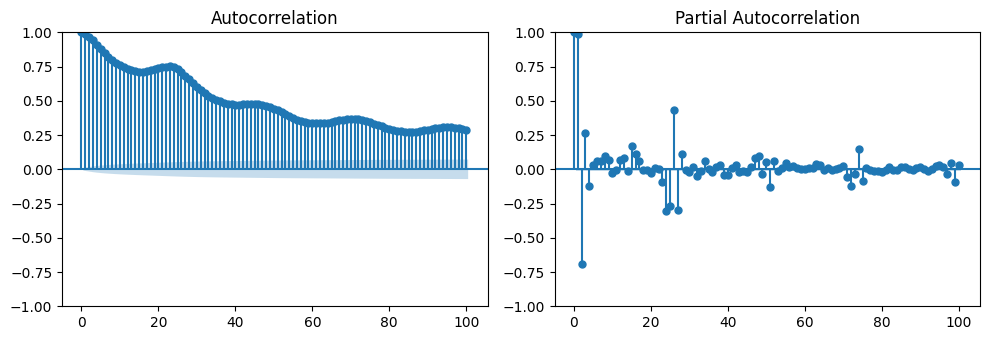

In [72]:
# 1か月の差分をとる
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_acf(train["PJME_MW"][-24*365*5:].diff(periods=24*30).dropna(), lags=100, ax=axes[0])
plot_pacf(train["PJME_MW"][-24*365*5:].diff(periods=24*30).dropna(), lags=100, ax=axes[1])
plt.tight_layout()
plt.show()

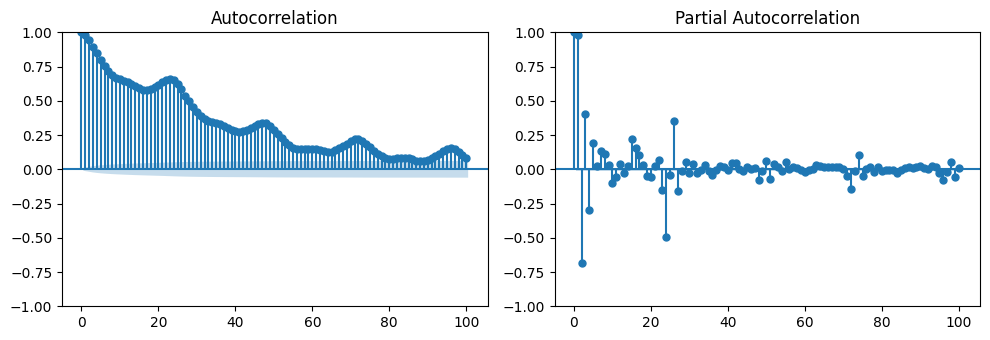

In [73]:
# 1年間の差分をとる
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_acf(train["PJME_MW"][-24*365*5:].diff(periods=24*365).dropna(), lags=100, ax=axes[0])
plot_pacf(train["PJME_MW"][-24*365*5:].diff(periods=24*365).dropna(), lags=100, ax=axes[1])
plt.tight_layout()
plt.show()

In [74]:
# 1週間、1年の差分は安定しない。

## 要素分解

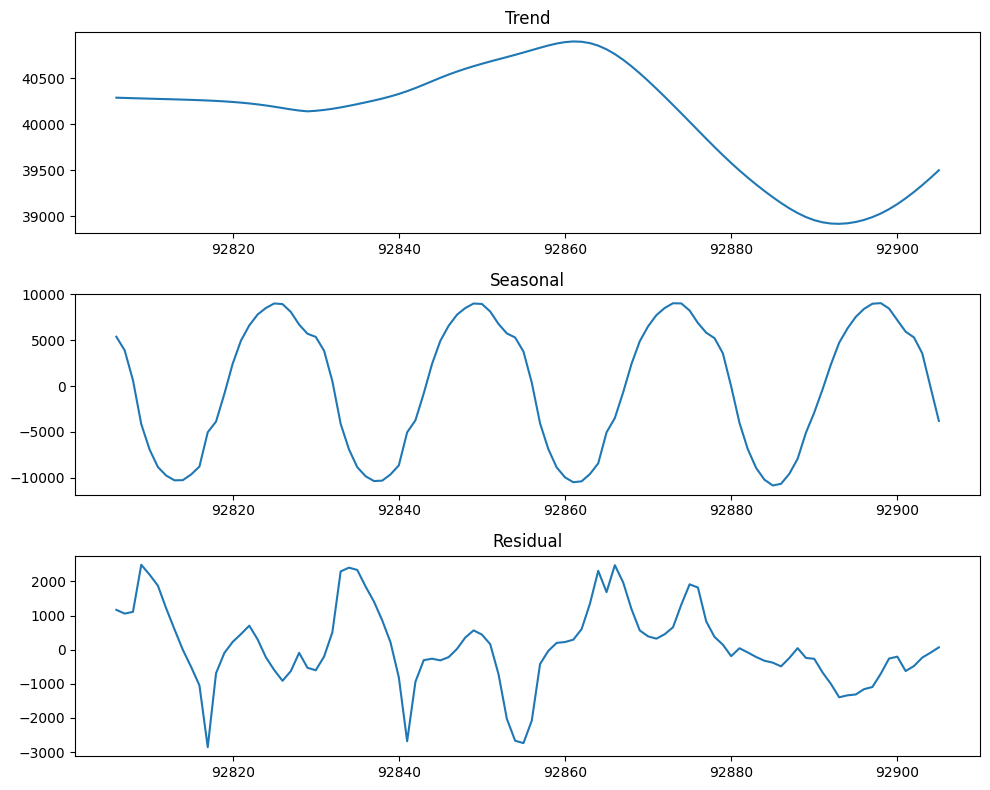

In [75]:
# トレンド、季節性、残差に分解してみる
from statsmodels.tsa.seasonal import STL

res = STL(train["PJME_MW"][-24*365*5:], period=24, robust=True).fit()
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
res.trend.iloc[:100].plot(ax=axes[0], title="Trend")
res.seasonal.iloc[:100].plot(ax=axes[1], title="Seasonal")
res.resid.iloc[:100].plot(ax=axes[2], title="Residual")
plt.tight_layout()
plt.show()

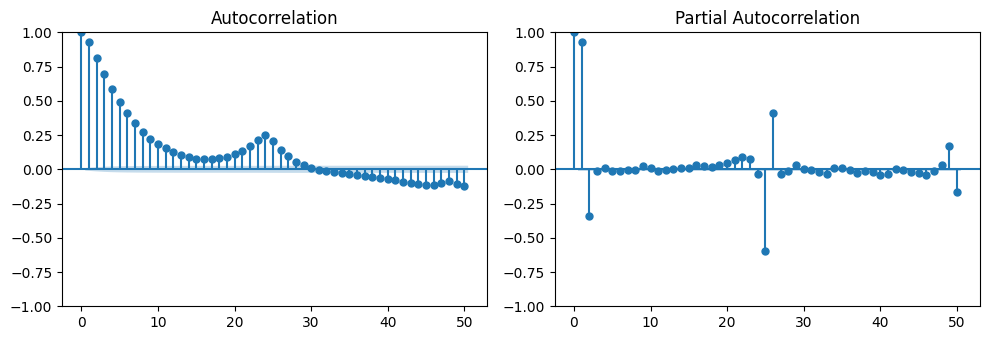

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_acf(res.resid.dropna(), lags=50, ax=axes[0])
plot_pacf(res.resid.dropna(), lags=50, ax=axes[1])
plt.tight_layout()
plt.show()

## 年、月、曜日

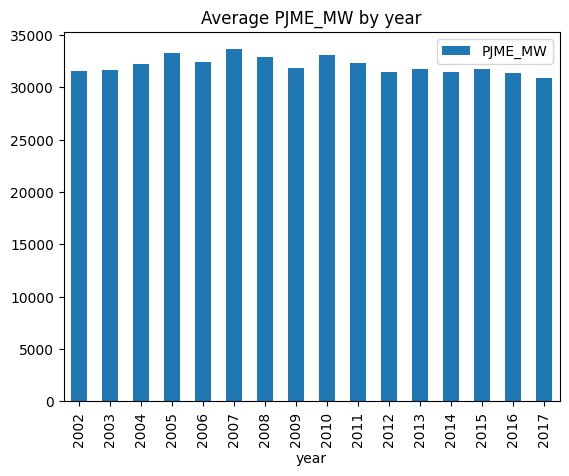

In [77]:
# 年ごとの平均を見てみる
train["year"] = train["Datetime"].dt.year
train[["PJME_MW", "year"]].groupby("year").mean().plot(kind="bar", title="Average PJME_MW by year")
plt.show()

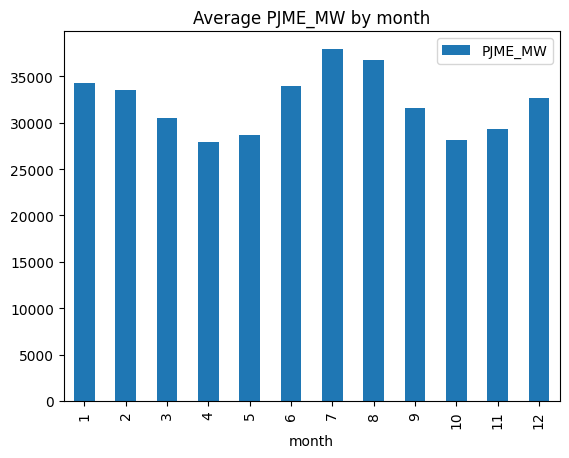

In [78]:
# 月ごとの平均を見てみる
train["month"] = train["Datetime"].dt.month
train[["PJME_MW", "month"]].groupby("month").mean().plot(kind="bar", title="Average PJME_MW by month")
plt.show()

In [79]:
# 年周期もありそう

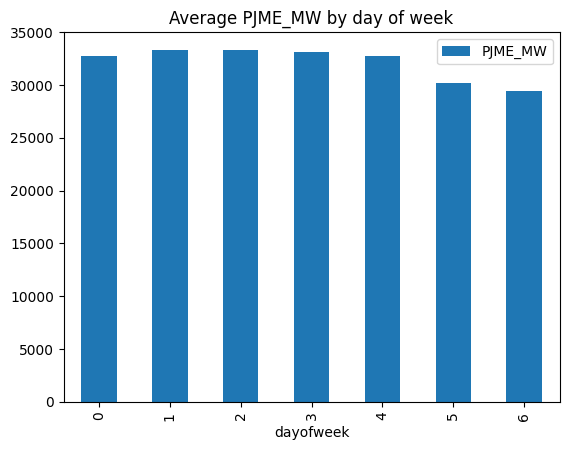

In [80]:
# 曜日ごとの平均を見てみる
train["dayofweek"] = train["Datetime"].dt.dayofweek
train[["PJME_MW", "dayofweek"]].groupby("dayofweek").mean().plot(kind="bar", title="Average PJME_MW by day of week")
plt.show()


In [81]:
# 周期性はなさそう
# 土日（週末）は電力消費が小さい可能性がある。
# 平日と週末で特徴量を分ける必要があるかもしれない。

## 祝日

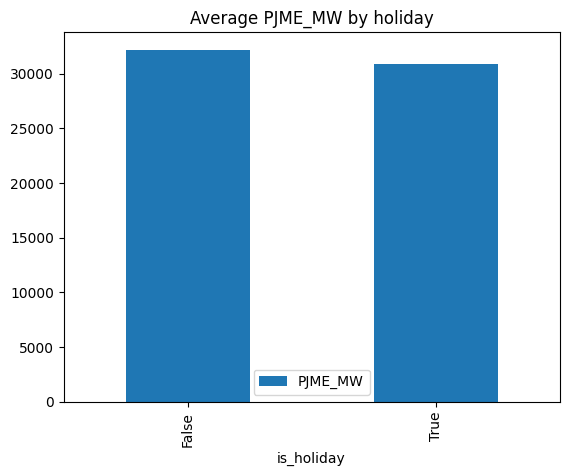

In [100]:
import holidays

us_holidays = holidays.CountryHoliday("US")
train["is_holiday"] = train["Datetime"].dt.date.apply(lambda x: x in us_holidays)
train[["PJME_MW", "is_holiday"]].groupby("is_holiday").mean().plot(kind="bar", title="Average PJME_MW by holiday")
plt.show()

In [83]:
# 祝日かどうかは電力消費に関係なさそう。
# 一応勾配ブースティング系のモデルを使うときの特徴量として、祝日かどうかを入れてもいいかもしれない。

## ローリング特徴量

### 移動平均

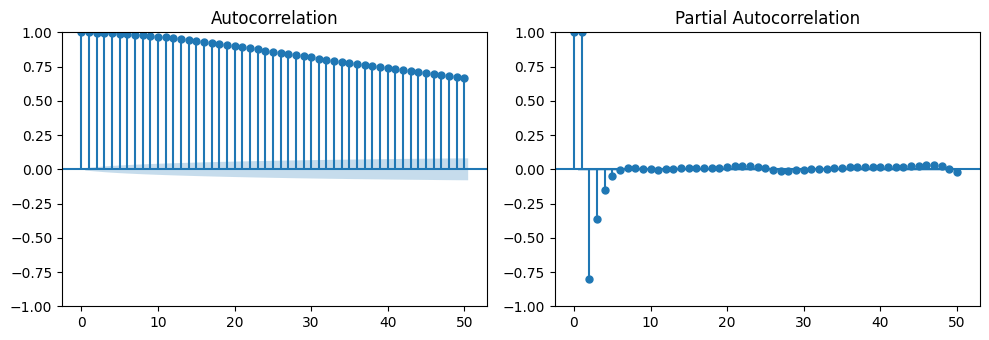

In [84]:
# 1日の平均を見てみる
roll_day = train["PJME_MW"].rolling(window=24).mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_acf(roll_day.dropna()[-24*365*5:], lags=50, ax=axes[0])
plot_pacf(roll_day.dropna()[-24*365*5:], lags=50, ax=axes[1])
plt.tight_layout()
plt.show()

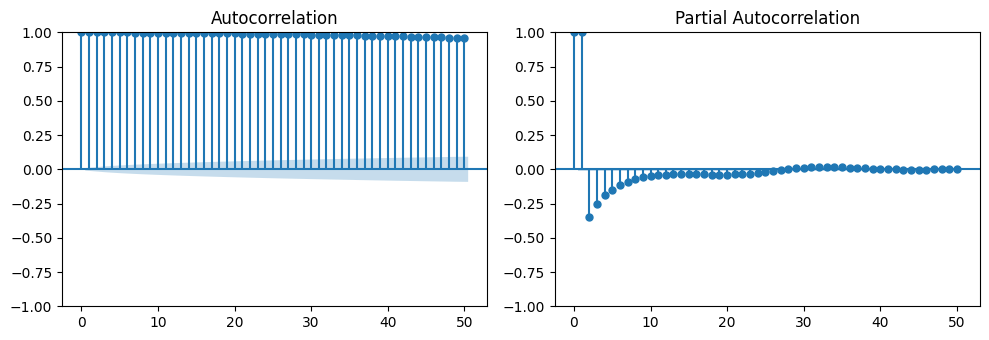

In [85]:
# 週の平均を見てみる
roll_week = train["PJME_MW"].rolling(window=24*7).mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_acf(roll_week.dropna()[-24*365*5:], lags=50, ax=axes[0])
plot_pacf(roll_week.dropna()[-24*365*5:], lags=50, ax=axes[1])
plt.tight_layout()
plt.show()

In [86]:
# 1日と1週間の移動平均は、自己相関・偏自己相関ともに安定するが、1週間の方は自己相関の減衰が比較的緩やかであり、lag=50でも自己相関が0.9以上あるため、1週間の移動平均はノイズとともに必要な情報を削減してしまう可能性がある。

### 移動標準偏差

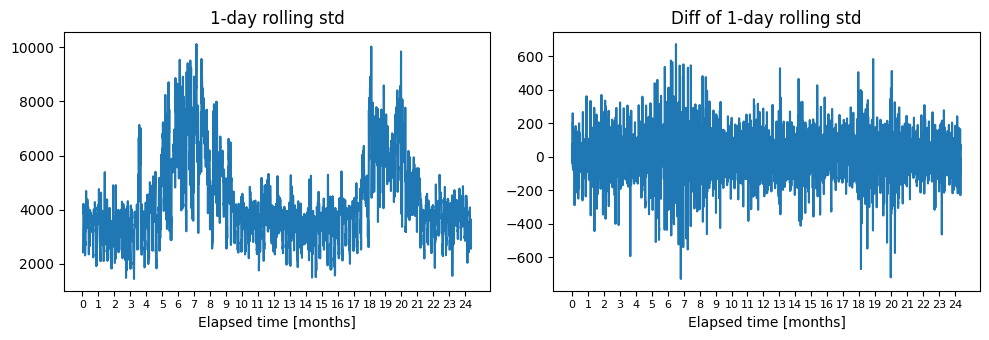

In [87]:
# 1日の標準偏差を見てみる
roll_day_std = train["PJME_MW"].rolling(window=24).std()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
roll_day_std.dropna()[:24*365*2].plot(title="1-day rolling std", ax=axes[0])
axes[0].set_xticks(np.arange(0, 24*365*2, 24*30), 
                   [i for i in range(0, len(np.arange(0, 24*365*2, 24*30)))], fontsize=8)
axes[0].set_xlabel("Elapsed time [months]", fontsize=10)
roll_day_std.diff().dropna()[:24*365*2].plot(title="Diff of 1-day rolling std", ax=axes[1])
axes[1].set_xticks(np.arange(0, 24*365*2, 24*30), 
                   [i for i in range(0, len(np.arange(0, 24*365*2, 24*30)))], fontsize=8)
axes[1].set_xlabel("Elapsed time [months]", fontsize=10)

plt.tight_layout()
plt.show()

In [88]:
# プロットに周期性らしさは見られるが、ノイズが大きい。

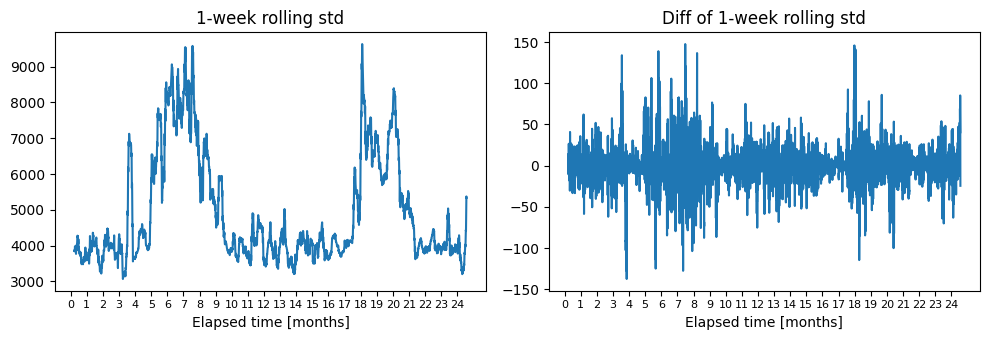

In [89]:
# 週の標準偏差を見てみる
roll_day_std = train["PJME_MW"].rolling(window=24*7).std()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
roll_day_std.dropna()[:24*365*2].plot(title="1-week rolling std", ax=axes[0])
axes[0].set_xticks(np.arange(0, 24*365*2, 24*30), 
                   [i for i in range(0, len(np.arange(0, 24*365*2, 24*30)))], fontsize=8)
axes[0].set_xlabel("Elapsed time [months]", fontsize=10)
roll_day_std.diff().dropna()[:24*365*2].plot(title="Diff of 1-week rolling std", ax=axes[1])
axes[1].set_xticks(np.arange(0, 24*365*2, 24*30), 
                   [i for i in range(0, len(np.arange(0, 24*365*2, 24*30)))], fontsize=8)
axes[1].set_xlabel("Elapsed time [months]", fontsize=10)

plt.tight_layout()
plt.show()

In [90]:
# 1日の標準偏差よりもノイズの影響は抑えられている。

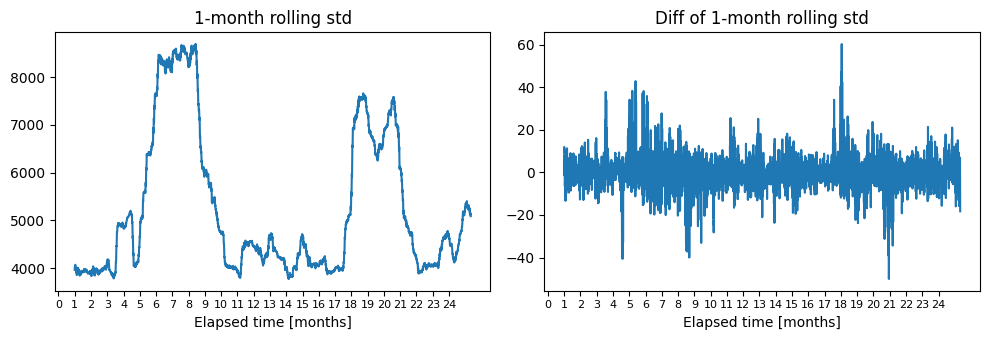

In [91]:
# 月の標準偏差を見てみる
roll_month_std = train["PJME_MW"].rolling(window=24*30).std()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
roll_month_std.dropna()[:24*365*2].plot(title="1-month rolling std", ax=axes[0])
axes[0].set_xticks(np.arange(0, 24*365*2, 24*30), 
                   [i for i in range(0, len(np.arange(0, 24*365*2, 24*30)))], fontsize=8)
axes[0].set_xlabel("Elapsed time [months]", fontsize=10)
roll_month_std.diff().dropna()[:24*365*2].plot(title="Diff of 1-month rolling std", ax=axes[1])
axes[1].set_xticks(np.arange(0, 24*365*2, 24*30), 
                   [i for i in range(0, len(np.arange(0, 24*365*2, 24*30)))], fontsize=8)
axes[1].set_xlabel("Elapsed time [months]", fontsize=10)

plt.tight_layout()
plt.show()

In [92]:
# 月の標準偏差は、1日の標準偏差や1週間の標準偏差よりもノイズの影響がさらに抑えられており、周期性も見られる。

## フーリエ変換

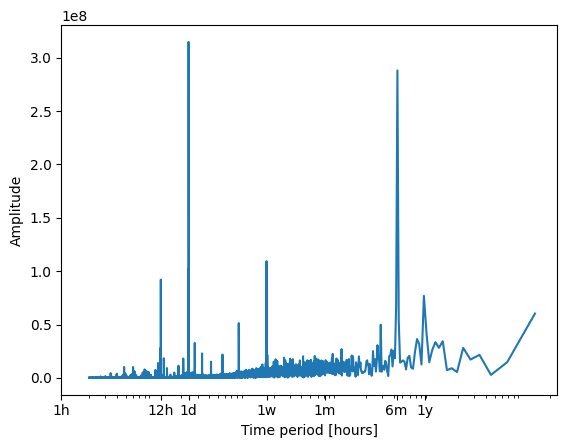

In [93]:
sf = 1 / 3600
dt = 1 / sf
N = len(train)

F = np.fft.rfft(train["PJME_MW"])
freq = np.fft.rfftfreq(N, d=dt)
plt.plot((1/freq) / 3600, np.abs(F))
plt.xscale("log")
plt.xlabel("Time period [hours]", fontsize=10)
plt.ylabel("Amplitude", fontsize=10)
plt.xticks([1, 12, 24, 24*7, 24*30, 24*30*6, 24*365], ["1h", "12h", "1d", "1w", "1m", "6m", "1y"])
plt.show()

In [94]:
# 周期性は、半日、1日、1週間、1か月、半年、1年の周期があるように見える。

# まとめ

時系列モデルは以下を検討する。  
- 古典的統計モデル（ARIMA, SARIMA）
- 構造的時系列モデル（Prophet）
- 勾配ブースティング木（LightGBM）
- ディープラーニングモデル（LSTM, GRU, Transformer）

予測は1日分（24ステップ）。テストデータは測定後のデータを入力として使えるものとする。

## 作成する特徴量

### 古典的統計モデル

In [95]:
# 作成する特徴量はない。

## 構造的時系列モデル

In [96]:
# 外部変数として、平日か週末、祝日かどうかを加える

## 勾配ブースティング木モデル

In [ ]:
# lag=1, 2, 24, 24*7
# 1時間の差分
# 時、日、曜日、月の特徴量
# 半日、1日、1週間、1か月、半年、1年の周期性を示す正弦・余弦特徴量
# 1日の移動平均
# 月の移動標準偏差
# 平日か週末かどうか
# 休日かどうか

## ディープラーニングモデル

In [98]:
# lag=1, 2, 24, 24*7
# 1時間の差分
# 半日、1日、1週間、1か月、半年、1年の周期性を示す正弦・余弦特徴量
# 1日の移動平均
# 月の移動標準偏差
# 平日・週末を示すカテゴリ変数
# 休日を示すカテゴリ変数
# ウィンドウサイズ、シフトは調整パラメータの候補となる。少なくとも1日分のウィンドウサイズは欲しい。